## Correcting for the throughput curve of the grating/filter pair

TLDR if you want to correct the shape of the throughput curve in your ETC sims, to get a bit closer to an idea of what a JWST observation with your specifications would actually _look_ like, this is for you.  This notebook does two things:

1. calculates the throughput curve using the setup we defined in `basics-pandeia.ipynb`
2. uses that curve to correct the shape of the flux spectrum of our ETC source output and also add random noise (based upon the estimated noise provided by the S/N ETC spectrum)

----
Author: Taylor Hutchison  
Email: astro.hutchison@gmail.com

In [1]:
from pandeia.engine.perform_calculation import perform_calculation # for the throughput curve

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, pickle
import pandas as pd # Taylor's favorite way to do spectra

In [3]:
# reading in the results from the other notebook
with open('result.pkl','rb') as r:
    result = pickle.load(r)

# extracting total science time
total_time = result['information']['exposure_specification']['total_exposure_time'] / 3600 # hr

### Throughput Curves

First we need to make a throughput curve for the ETC spectroscopic sim we just ran.  Doing this is pretty simple if you still have the calculation setup from that sim -- essentially we take that setup and ONLY change the sed to be a flat continuum (and make the source a point source if it's not).  That's all that's needed.

In [4]:
# reading in the setup json we made in the other notebook
with open('setup.json') as setup_data:
    setup = json.load(setup_data)

setup.keys()

dict_keys(['configuration', 'scene', 'background', 'background_level', 'calculation', 'strategy'])

In [5]:
# making the sed key be a flat fnu continuum
setup['scene'][0]['spectrum']['sed']['sed_type'] = 'flat'
setup['scene'][0]['spectrum']['sed']['unit'] = 'fnu'

# running
throughput = perform_calculation(setup)

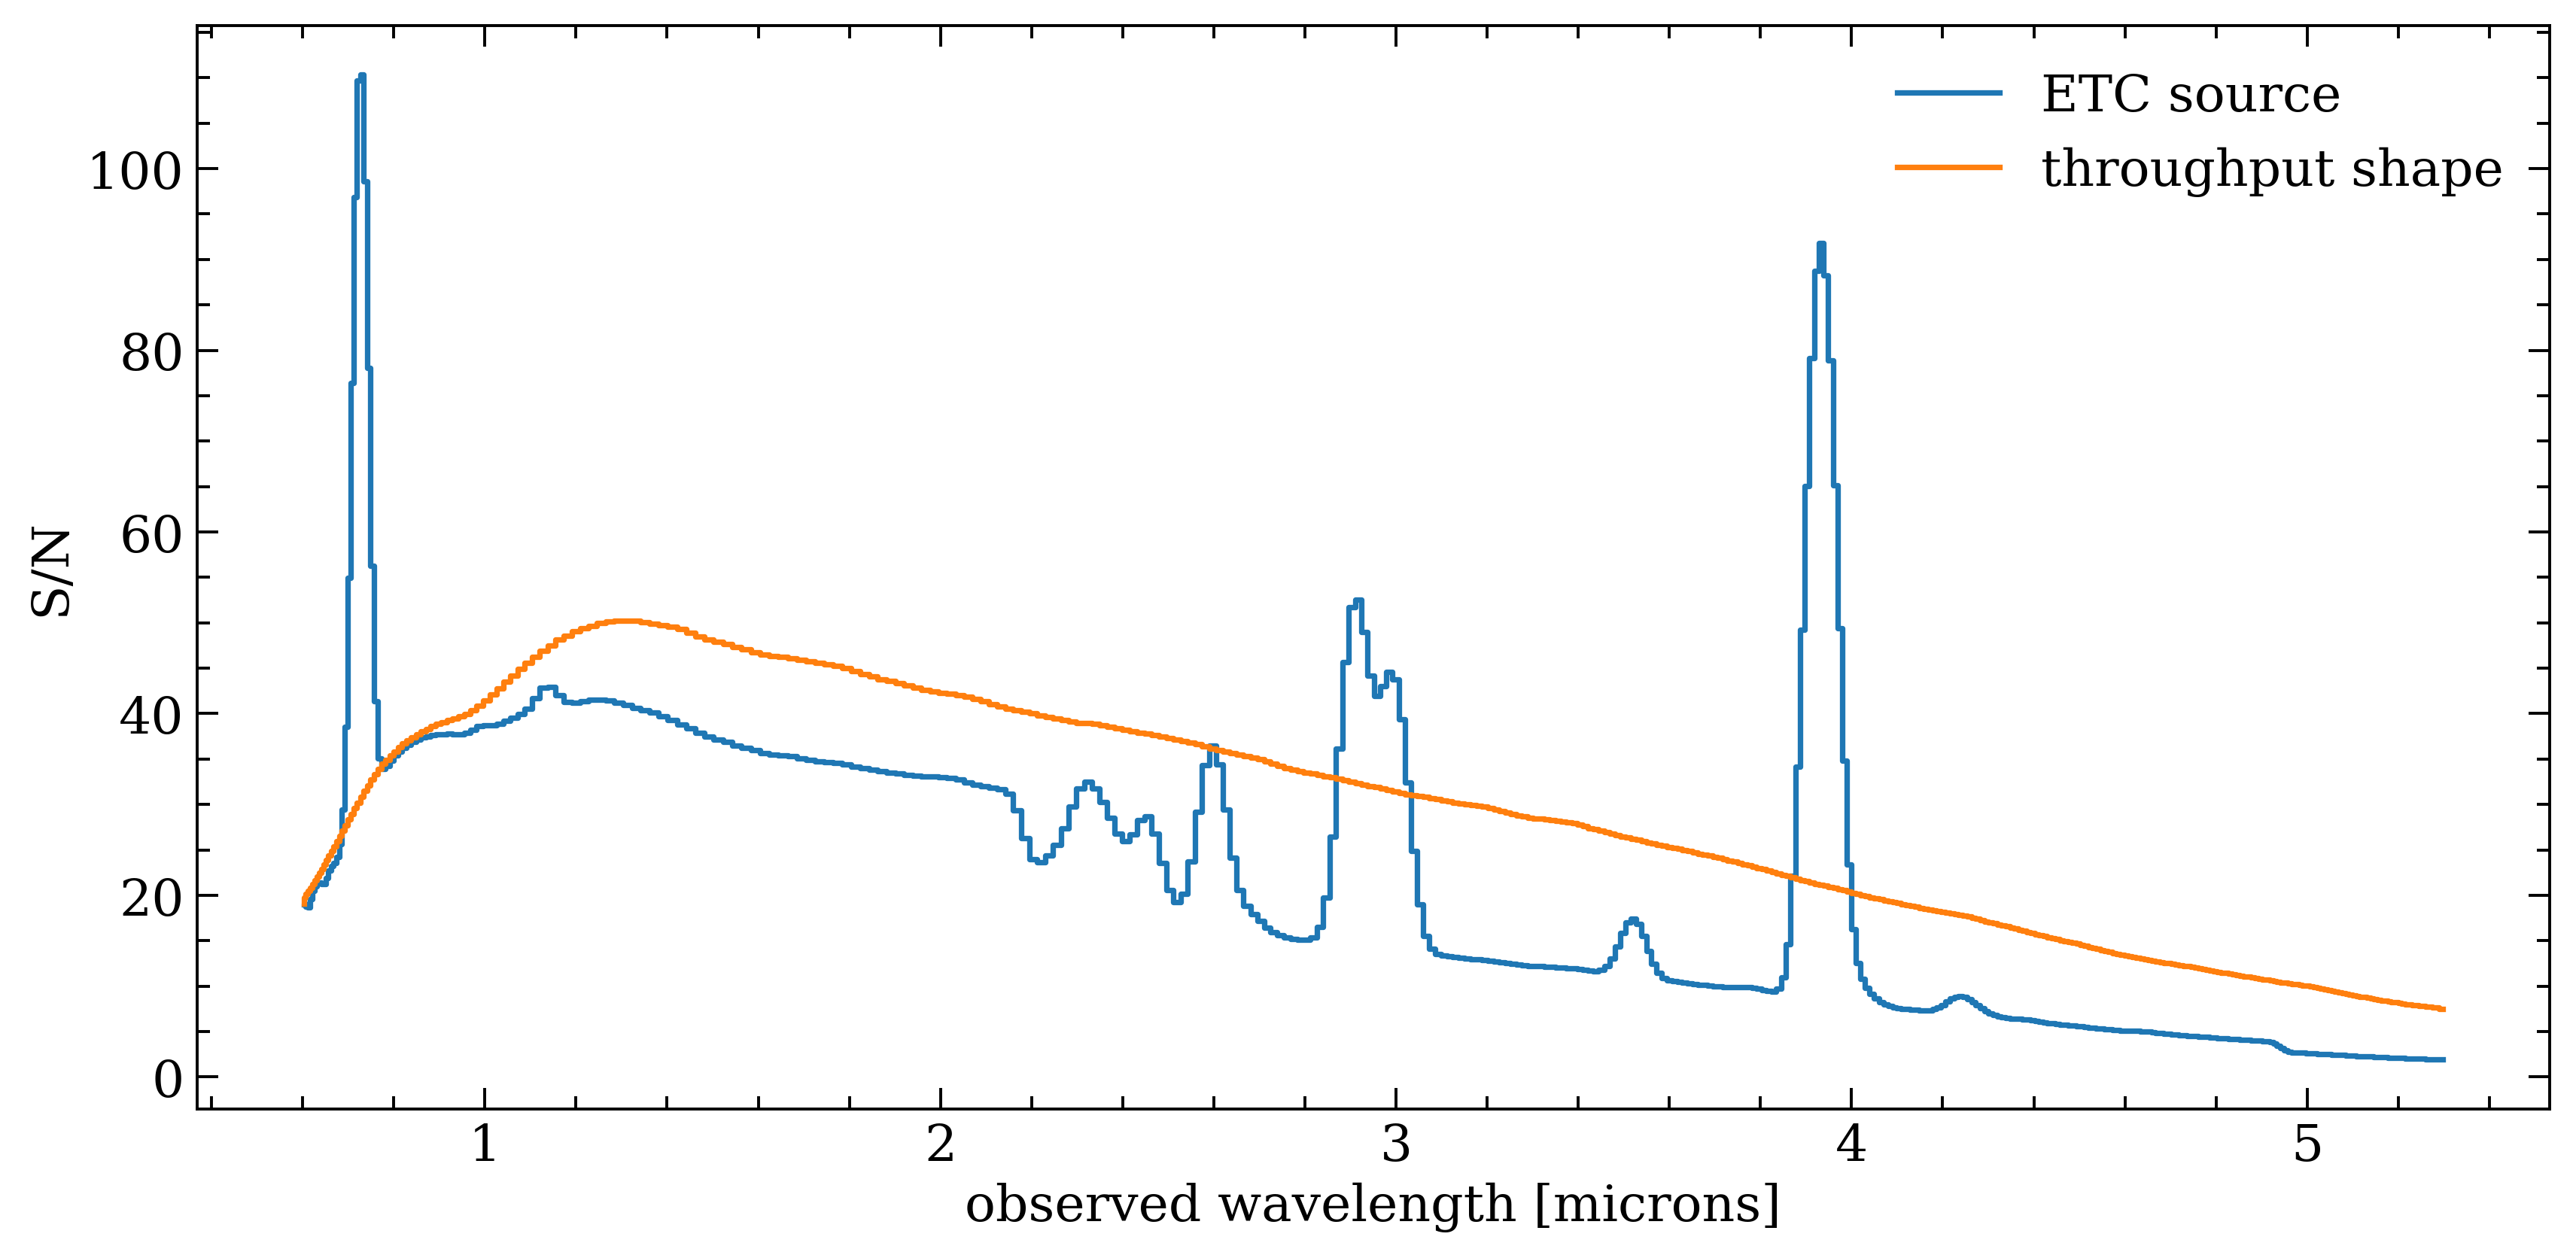

In [6]:
# Looking at the S/N spectra for both
plt.figure(figsize=(10,5))

plt.step(result['1d']['sn'][0],result['1d']['sn'][1],label='ETC source')
plt.step(throughput['1d']['sn'][0],throughput['1d']['sn'][1],label='throughput shape')

plt.xlabel('observed wavelength [microns]')
plt.ylabel('S/N')
plt.legend()

plt.tight_layout()
plt.show()
plt.close('all')

Don't worry about the strength of the throughput curve -- we normalize it in the next step so that isn't a problem.

### Correcting the sim & adding noise

This will take out the bump you see in the S/N spectrum above -- which is just telling you where the grating/filter pair is the most sensitive/best throughput.  NOTE that we only do this for the `extracted_flux` 1D outputs, _not_ for the S/N spectrum.

We'll also be adding estimated noise to the corrected spectrum (to better simulate what it may look like).  We can do this using the S/N spectrum and the `extracted_flux` spectrum outputs.

In [7]:
# using pandas dataframes, let "make" our spectrum file
wave = result['1d']['extracted_flux'][0] # units microns
flux = result['1d']['extracted_flux'][1]
snr = result['1d']['sn'][1] # wave array is the same

spec = pd.DataFrame({'wave':wave,'flux':flux,'snr':snr})

In [8]:
# adding noise by using the S/N spectrum and the flux spectrum
spec['noise'] = spec.flux / spec.snr

In [9]:
# prepping the throughput curve, normalizing to sum to 1
thru = throughput['1d']['extracted_flux'][1] / np.sum(throughput['1d']['extracted_flux'][1]) 

In [10]:
# correcting spectra with the throughput curve
spec['flux'] = spec.flux / thru
spec['noise'] = spec.noise / thru # doing separately before adding to flux

In [11]:
# adding random noise to the flux spectrum, based on estimated ETC noise
spec['flux'] = np.random.normal(loc=spec.flux,scale=spec.noise)

In [12]:
# saving throughput curve in the spec dataframe for bookkeeping purposes
spec['thru'] = thru.copy()

In [13]:
# saving the sim spectrum
spec.to_csv('simulated_spectrum_corrected_withnoise.txt',sep='\t',index=False)

### Let's look at the result!

#### --- the original extracted\_flux spectrum

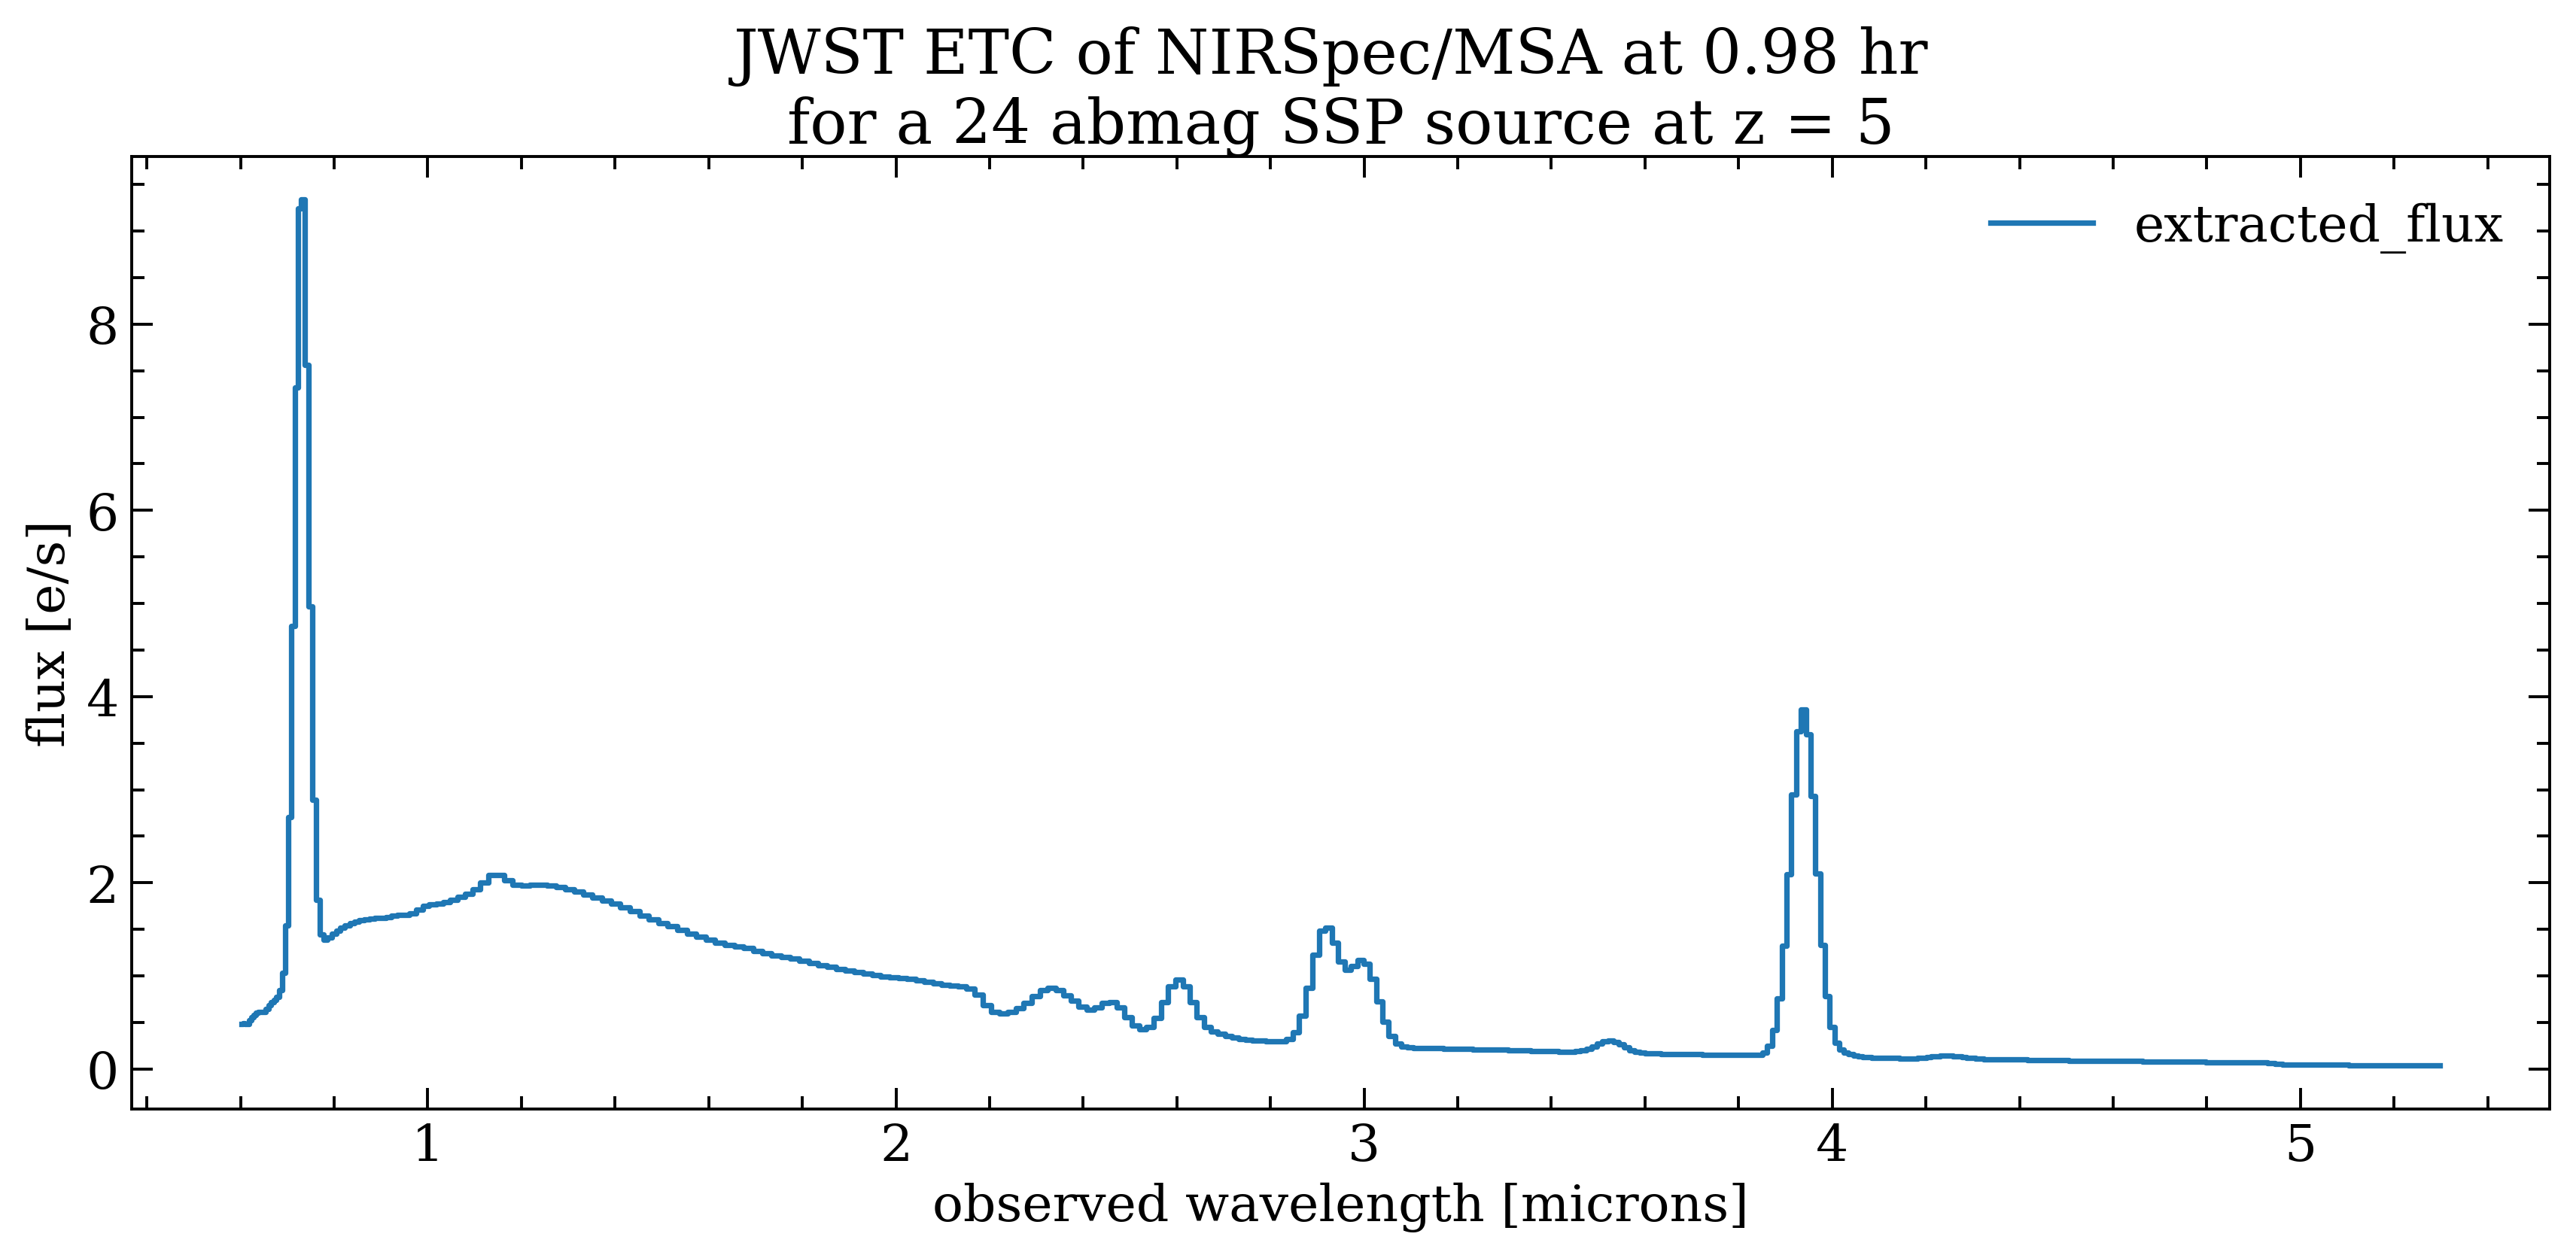

In [14]:
# First looking at the before (i.e., straight-from-the-ETC-output)
plt.figure(figsize=(10,5))

plt.title(f'JWST ETC of NIRSpec/MSA at {round(total_time,2)} hr \nfor a 24 abmag SSP source at z = 5')
plt.step(spec.wave,result['1d']['extracted_flux'][1],where='mid',label='extracted_flux')

plt.ylabel('flux [e/s]')
plt.xlabel('observed wavelength [microns]')
plt.legend()

plt.tight_layout()
plt.show()
plt.close('all')

#### --- the "corrected" flux spectrum

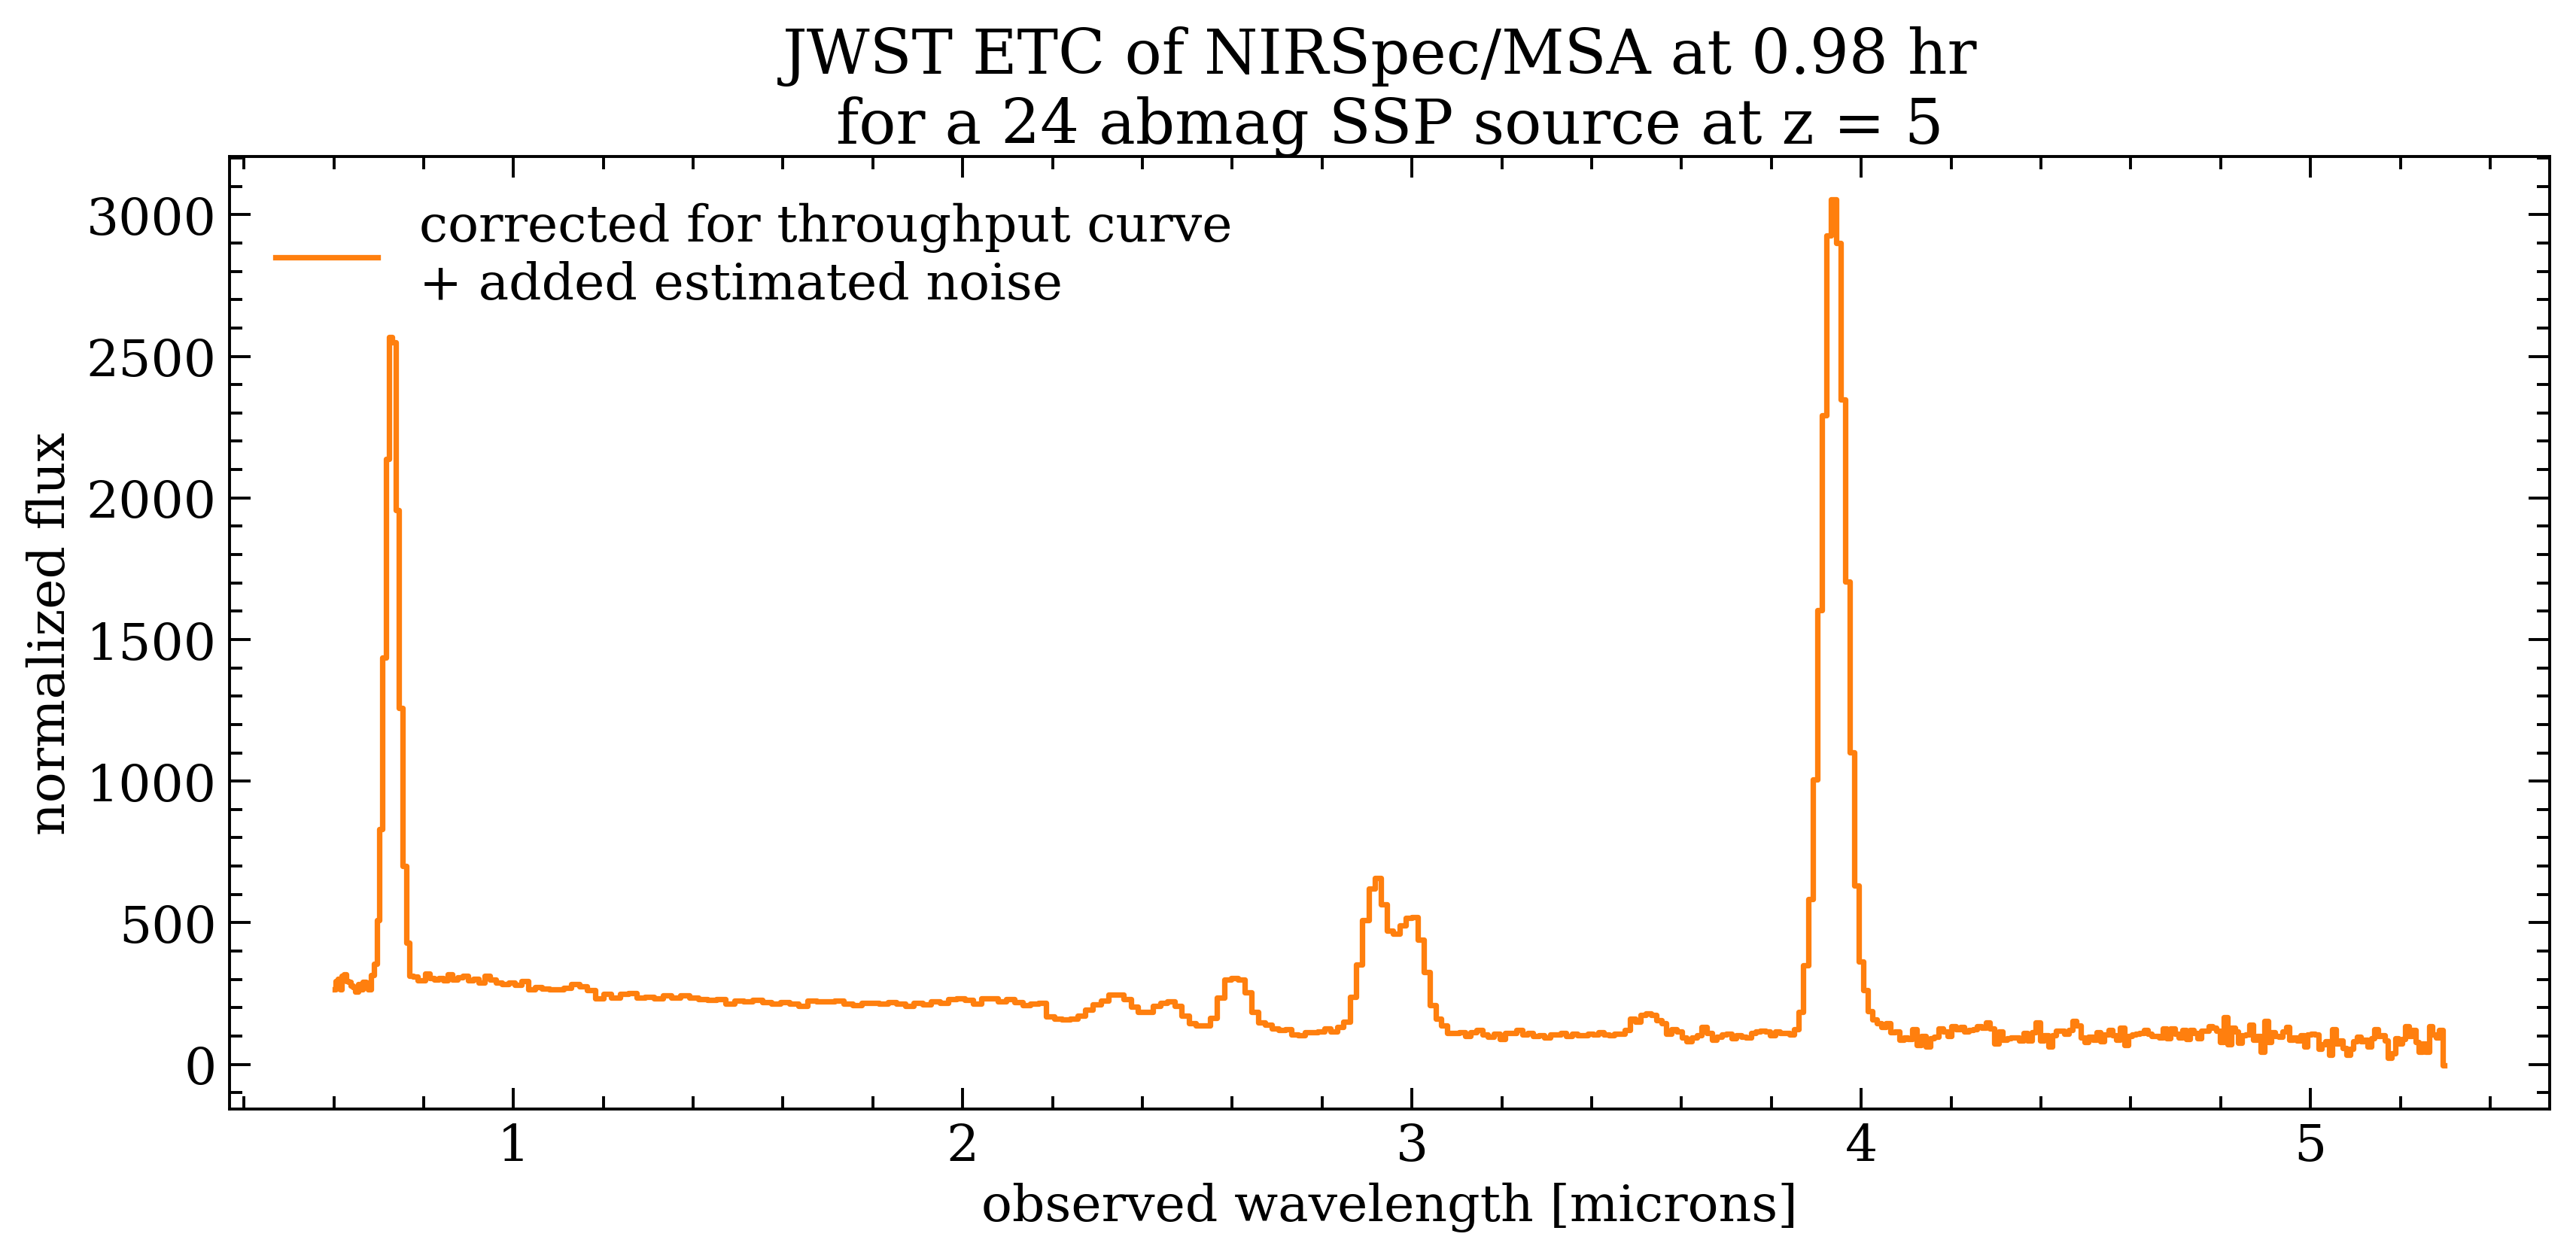

In [15]:
# the "corrected" flux shape
plt.figure(figsize=(10,5))

plt.title(f'JWST ETC of NIRSpec/MSA at {round(total_time,2)} hr \nfor a 24 abmag SSP source at z = 5')
plt.step(spec.wave,spec.flux,where='mid',label='corrected for throughput curve \n+ added estimated noise',color='C1')

plt.ylabel('normalized flux')
plt.xlabel('observed wavelength [microns]')
plt.legend()

plt.tight_layout()
plt.show()
plt.close('all')

### That's it!

Hopefully that can get you started.  Go forth & propose!